## Notebook 01 — Data Preprocessing, Feature Engineering & EDA (Nairobi Ride‑Hailing)

### What this notebook delivers
- **Clean + feature-engineered dataset** saved to `outputs/trips_processed.parquet`
- **Reproducible preprocessing metadata** in `outputs/preprocess_metadata.json`
- **EDA plots** saved to `outputs/figures/`
- **Spatial hotspot maps** saved to `outputs/maps/`
- neighborhood-level aggregation,a Nairobi boundaries file (GeoJSON/Shapefile)

### Notes on the surge target
We use the  `surge_multiplier` column from the data .

**Surge event (classification target):** Per data provider definition, **surge_event** = 1 when `surge_multiplier` > 0 (strictly greater than zero), else 0. The threshold is set in `ModelingConfig.surge_event_threshold` (0) and is used for the binary classifier in notebook 02.


### Setup & configuration

Paths and dependencies are configured below.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Stable imports whether executed from repo root or notebooks/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ColumnMap, ModelingConfig  # noqa: E402
from src.data import maybe_merge_weather_hourly, preprocess_trips, save_parquet  # noqa: E402
from src.neighborhoods import detect_name_column, load_neighborhood_boundaries, spatial_join_points_to_polygons, export_hotspots_to_geojson  # noqa: E402
from src.spatial_maps import (  # noqa: E402
    attach_grid_centroids,
    build_folium_heatmap,
    build_hotspot_marker_map,
    grid_hotspots,
    kmeans_cluster_surge_hotspots,
    save_folium_map,
)

sns.set_theme(style="whitegrid")

# New JSON data with surge column
DATA_JSON = PROJECT_ROOT / "data" / "New Files" / "trip_analysis_data.json"
WEATHER_CSV = PROJECT_ROOT / "data" / "weather_nairobi_hourly.csv"  # optional

# Neighborhood shapefile from New Files
NEIGHBORHOODS_SHP = PROJECT_ROOT / "data" / "New Files" / "nairobi_neighborhoods.shp"
NEIGHBORHOODS_GEOJSON = PROJECT_ROOT / "data" / "nairobi_neighborhoods.geojson"  # fallback if exists

OUT_PARQUET = PROJECT_ROOT / "outputs" / "trips_processed.parquet"
OUT_META = PROJECT_ROOT / "outputs" / "preprocess_metadata.json"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
MAP_DIR = PROJECT_ROOT / "outputs" / "maps"

FIG_DIR.mkdir(parents=True, exist_ok=True)
MAP_DIR.mkdir(parents=True, exist_ok=True)

cols = ColumnMap()
cfg = ModelingConfig()



### 1) Load + preprocess

We parse timestamps, validate coordinates, remove obvious outliers, then build temporal/spatial features.

**Methodology note (date range):** The dataset spans Jan–Jul 2024. All temporal features (hour, day of week, month) and weather merges are aligned to this range. For reproducibility, the exact range is printed below.


In [2]:

NROWS = None

# preprocess_trips(): parses timestamps, validates coords (Nairobi box), removes outliers
# (distance 0.1–200 km, duration 0.5–600 min), adds temporal (hour_sin/cos, peak flags),
# spatial (haversine, grid IDs), trip-quality (speed_kmh), and target (surge_event)
df, meta = preprocess_trips(data_path=DATA_JSON, cols=cols, cfg=cfg, nrows=NROWS)

# maybe_merge_weather_hourly(): joins hourly weather (temp_c, precip_mm, wind_kph, humidity)
# on ts_hour; full coverage if weather spans the trip date range
df, weather_meta = maybe_merge_weather_hourly(df, WEATHER_CSV)
meta.update(weather_meta)

# rain_flag: 1 when precip_mm > 0 (binary indicator for weather-triggered surge)
if "precip_mm" in df.columns:
    df["rain_flag"] = (df["precip_mm"] > 0).astype("int8")

print("Processed shape:", df.shape)
print("Target mode used:", meta.get("target_mode_used"))
# Dataset time range (essential context for EDA and modeling)
ts_col = "ts_utc" if "ts_utc" in df.columns else cols.ts
if ts_col in df.columns:
    print("Data range:", df[ts_col].min(), "to", df[ts_col].max())


Processed shape: (3703406, 45)
Target mode used: real_surge
Data range: 2024-01-11 00:00:57.476000+00:00 to 2024-07-10 23:59:50.928000+00:00


**Observations and interpretation (load + preprocess):**
- *Sample size:* 3.7M trips after preprocessing; coordinate and outlier filters remove invalid records.
- *Date range:* Jan 11 – Jul 10, 2024; all temporal and weather features align to this range.
- *Target:* `surge_event` = 1 when `surge_multiplier` > 0 (per data provider); used as binary target in modeling.

**Feature engineering (methodology):**
- *Temporal encoding:* `hour_sin` = sin(2π×hour/24), `hour_cos` = cos(2π×hour/24) for cyclical hour; same pattern for `dow_sin/cos` and `month_sin/cos`. Preserves 23h–0h continuity for models.
- *Peak flags:* `is_morning_peak` = hour ∈ [7, 10]; `is_evening_peak` = hour ∈ [16, 20]. Nairobi ride-hailing peaks; used as model inputs.
- *rain_flag:* 1 when precip_mm > 0 (from merged weather); binary indicator for rain-triggered surge.

In [3]:
# Check surge column distribution and class imbalance
print("Surge column statistics:")
print(df['surge_multiplier'].describe())
print(f"\nSurge = 0 count: {(df['surge_multiplier'] == 0).sum():,}")
print(f"Surge > 0 count: {(df['surge_multiplier'] > 0).sum():,}")
print(f"Surge event rate (surge > {cfg.surge_event_threshold}): {df['surge_event'].mean():.4f}")
print(f"\nClass imbalance ratio (negative:positive): {(df['surge_event'] == 0).sum() / (df['surge_event'] == 1).sum():.2f}:1")

Surge column statistics:


count    3.703406e+06
mean     6.001727e-02
std      1.662815e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.000000e+00
Name: surge_multiplier, dtype: float64

Surge = 0 count: 2,998,548
Surge > 0 count: 704,858
Surge event rate (surge > 0.0): 0.1903

Class imbalance ratio (negative:positive): 4.25:1


In [4]:
# Persist the processed dataset for downstream modeling + Streamlit
save_parquet(df, OUT_PARQUET)
OUT_META.write_text(json.dumps(meta, indent=2))
print("Saved:", OUT_PARQUET)
print("Saved:", OUT_META)


Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\trips_processed.parquet
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\preprocess_metadata.json


In [5]:
# Check weather merge status
print("Weather merge:", meta.get("weather_merge", "unknown"))
weather_cols = [c for c in df.columns if any(x in c.lower() for x in ['temp', 'precip', 'wind', 'humidity'])]
if weather_cols:
    print(f"\nWeather columns found: {weather_cols}")
    print(f"Non-null weather values: {df[weather_cols[0]].notna().sum():,} / {len(df):,} trips")
    if df[weather_cols[0]].notna().sum() > 0:
        print("\nSample weather stats:")
        print(df[weather_cols].describe().T)
else:
    print("No weather columns found in dataset")


Weather merge: OK (merged on ts_hour) from weather_nairobi_hourly.csv

Weather columns found: ['temp_c', 'precip_mm', 'wind_kph', 'humidity']
Non-null weather values: 3,703,406 / 3,703,406 trips

Sample weather stats:
               count       mean        std   min   25%   50%   75%   max
temp_c     3703406.0  21.465654   3.956266   9.4  18.1  21.6  24.7  31.1
precip_mm  3703406.0   0.131698   0.539333   0.0   0.0   0.0   0.1   9.1
wind_kph   3703406.0   8.441795   4.127209   0.0   5.5   7.8  10.9  24.2
humidity   3703406.0  63.526721  18.973925  18.0  48.0  61.0  80.0  99.0


#### Distributions of weather variables

Histograms (with KDE) for merged weather columns: temperature, precipitation, wind, humidity. Complements the summary stats and shows skew and outliers.

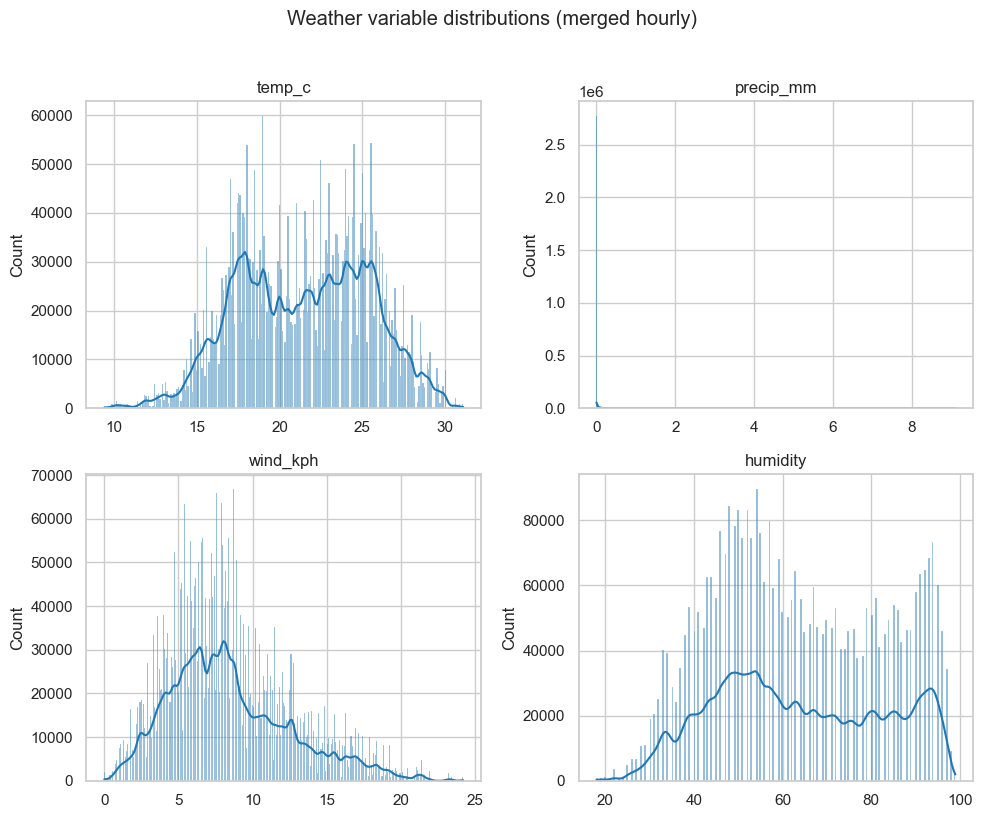

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\weather_distributions.png


In [6]:
# Weather variable distributions (2×2): histograms with KDE for merged hourly weather
# Each subplot shows one variable; dropna() excludes trips without weather match
weather_plot_cols = ["temp_c", "precip_mm", "wind_kph", "humidity"]
available = [c for c in weather_plot_cols if c in df.columns]
if available:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flat
    for i, col in enumerate(weather_plot_cols):
        ax = axes[i] if i < len(axes) else None
        if ax is not None and col in df.columns:
            sns.histplot(df[col].dropna(), kde=True, ax=ax, color="#1f77b4")
            ax.set_title(col)
            ax.set_xlabel("")
    for j in range(len(weather_plot_cols), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle("Weather variable distributions (merged hourly)", y=1.02)
    fig.tight_layout()
    out = FIG_DIR / "weather_distributions.png"
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)
else:
    print("No weather columns found. Skip weather distributions.")

**Interpretation: Weather Variable Distributions**

The figure above shows the distributions of key weather variables merged with the trip dataset on an hourly basis, including temperature, precipitation, wind speed, and humidity.

**Temperature (temp_c)**  
The temperature distribution ranges approximately between 10°C and 31°C, with most observations concentrated between 17°C and 26°C. This indicates relatively stable and moderate climatic conditions, which is typical for Nairobi due to its elevation and equatorial climate. The smooth distribution suggests that extreme temperature conditions are rare and therefore temperature is unlikely to create large sudden shocks in ride demand, though it may still influence passenger comfort and travel preferences.

**Precipitation (precip_mm)**  
The precipitation distribution is heavily skewed toward zero, indicating that the majority of hours experience little or no rainfall. Only a small number of observations show measurable precipitation. This suggests that rainfall events are relatively infrequent but potentially impactful. When rain does occur, it may significantly increase ride-hailing demand as passengers prefer private transport over walking or public transport. Justifies **rain_flag** (precip_mm > 0) for the model.

**Wind Speed (wind_kph)**  
Wind speed values are concentrated between 3 and 12 km/h, with a peak around 6–8 km/h. The distribution gradually declines for higher speeds, indicating that strong winds are relatively uncommon. Wind speed is therefore expected to have a minor influence on ride demand, though extreme values could still affect travel conditions.

**Humidity**  
Humidity values range broadly from around 30% to nearly 100%, with the majority of observations clustered between 45% and 70%. Higher humidity levels often coincide with cloudy or rainy weather conditions, which may indirectly affect ride demand.

**Overall Insight**  
Overall, the weather variables show moderate variability, with rainfall being the most irregular factor. Among the weather features, precipitation is likely the most influential variable for surge pricing, as rainfall events can increase passenger demand and temporarily create supply–demand imbalances in the ride-hailing system. The model uses **rain_flag** as the primary weather predictor.

### 2) Data quality checks
Duplicates, missingness, and basic sanity ranges.


#### Outlier and filter rules (methodology)

Preprocessing applies the following before feature engineering and modeling (see `src.data.clean_outliers` and `preprocess_trips`):

- **Drop missing:** Rows with missing timestamp or any of pickup/dropoff coordinates are dropped.
- **Nairobi bounding box:** Pickup and dropoff lat in [-2, 0], lon in [36, 38] (degrees).
- **Distance:** `total_distance` in [0.1, 200] km.
- **Duration:** `total_time` in [0.5, 600] minutes.

The printed "Processed shape" above is the row count *after* these filters. No separate before/after counts are stored in metadata; re-run with a copy of the raw data and compare shapes if you need exact drop counts.

In [7]:
# Missingness snapshot
missing = df.isna().mean().sort_values(ascending=False)
print("Top missing columns (%):")
print((missing.head(12) * 100).round(2))

# Quick numeric sanity
print(df[["total_distance", "total_time", "speed_kmh", "trip_haversine_km"]].describe().T)


Top missing columns (%):
zone_id                   4.74
destination_address       0.00
total_distance            0.00
total_time                0.00
source_address            0.00
created_at                0.00
surged                    0.00
sourceLocation[0]         0.00
sourceLocation[1]         0.00
destinationLocation[0]    0.00
destinationLocation[1]    0.00
surge_multiplier          0.00
dtype: float64
                       count       mean        std       min        25%  \
total_distance     3703406.0   7.590986   4.960978  0.100000   3.820000   
total_time         3703406.0  22.621059  13.403604  0.500000  12.450000   
speed_kmh          3703406.0  20.980448   9.243359  0.010105  14.359926   
trip_haversine_km  3703406.0   5.333582   4.152396  0.000229   2.433024   

                         50%        75%         max  
total_distance      6.670000  10.070000   19.505000  
total_time         19.700000  29.950000   56.145000  
speed_kmh          20.150975  26.471642  139.92932

In [8]:
# Exportable EDA summary table for report/thesis
ts_col = "ts_utc" if "ts_utc" in df.columns else cols.ts
summary = {
    "n_trips": len(df),
    "date_min": str(df[ts_col].min()) if ts_col in df.columns else "",
    "date_max": str(df[ts_col].max()) if ts_col in df.columns else "",
    "surge_event_rate_pct": round(100 * df["surge_event"].mean(), 2),
    "mean_surge_multiplier": round(float(df["surge_multiplier"].mean()), 4),
    "median_surge_multiplier": round(float(df["surge_multiplier"].median()), 4),
}
if "rain_flag" in df.columns:
    summary["pct_trips_with_rain"] = round(100 * df["rain_flag"].mean(), 2)
summary_df = pd.DataFrame([summary])
OUT_SUMMARY = PROJECT_ROOT / "outputs" / "eda_summary_table.csv"
summary_df.to_csv(OUT_SUMMARY, index=False)
print("Saved:", OUT_SUMMARY)
display(summary_df)

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\eda_summary_table.csv


,n_trips,date_min,date_max,surge_event_rate_pct,mean_surge_multiplier,median_surge_multiplier,pct_trips_with_rain
0,3703406,2024-01-11 00:00:57.476000+00:00,2024-07-10 23:59:50.928000+00:00,19.03,0.06,0.0,25.16


### 3) Core EDA — distributions

We focus on variables that affect surge dynamics: distance, duration, speed, and multiplier.


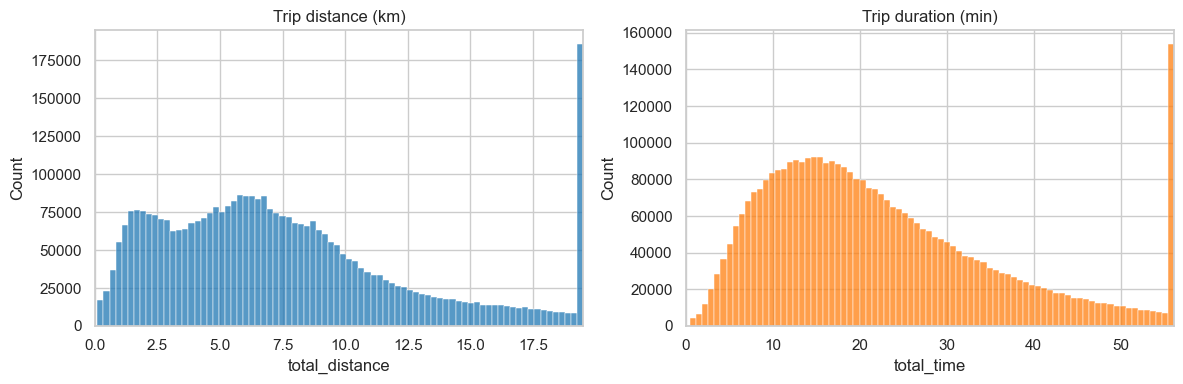

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\dist_distance_time.png


In [9]:
# Distance and time distributions (trim long tails for readability)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["total_distance"], bins=80, ax=ax[0], color="#1f77b4")
ax[0].set_title("Trip distance (km)")
ax[0].set_xlim(0, df["total_distance"].quantile(0.99))

sns.histplot(df["total_time"], bins=80, ax=ax[1], color="#ff7f0e")
ax[1].set_title("Trip duration (min)")
ax[1].set_xlim(0, df["total_time"].quantile(0.99))

fig.tight_layout()
out = FIG_DIR / "dist_distance_time.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Observations and interpretation (Distance and duration)**  
- **Distance:** Most trips are short (a few km); right-skewed with a long tail. Preprocessing caps distance to [0.1, 200] km.  
- **Duration:** Concentrated at 10–30 min with a long tail. Preprocessing caps duration to [0.5, 600] min; very long trips removed as outliers.  
- **Methodology:** Outlier treatment is documented in clean_outliers(); this figure motivates the caps.

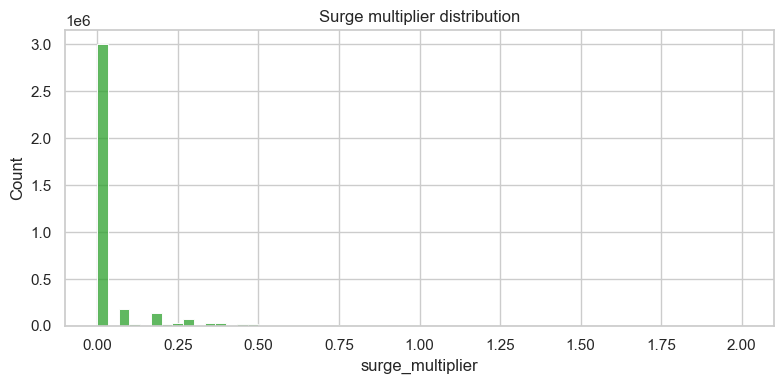

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\dist_surge_multiplier.png


In [10]:
# Multiplier distribution
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["surge_multiplier"], bins=60, ax=ax, color="#2ca02c")
ax.set_title("Surge multiplier distribution")
fig.tight_layout()
out = FIG_DIR / "dist_surge_multiplier.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Observations and interpretation (Surge multiplier distribution)**  
- **Mass at zero:** Most trips have surge_multiplier = 0; a smaller share has surge &gt; 0. Per data provider, surge_event = 1 when surge &gt; 0, giving severe class imbalance (negative:positive ~4.25:1 in this sample).  
- **Imbalance:** Justifies scale_pos_weight, stratified sampling (ratio_pos=0.2), and precision/recall focus in notebook 02.  
- **Max at 2.0:** Suggests a cap or natural ceiling in the data; surge_event definition uses threshold 0.

### 4) Core EDA — time patterns

We look at hour-of-day and day-of-week effects and also a heatmap (hour × weekday).


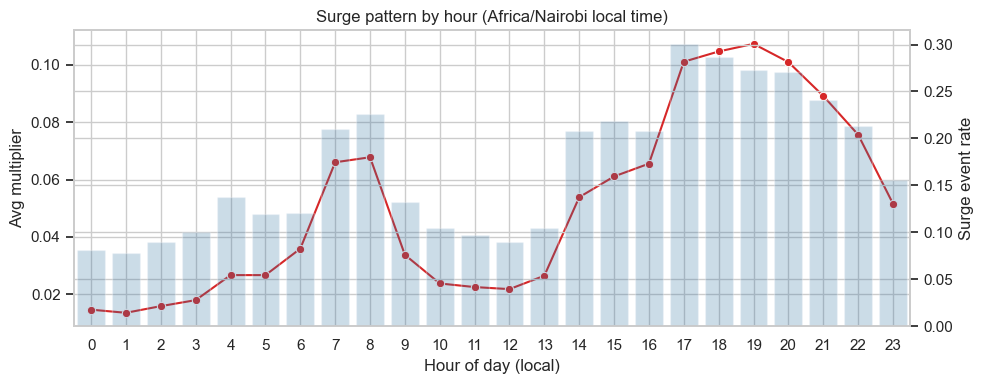

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\surge_by_hour.png


In [11]:
# Hourly pattern: average multiplier + surge event rate
by_hour = (
    df.groupby("hour", observed=True)
    .agg(avg_mult=("surge_multiplier", "mean"), surge_rate=("surge_event", "mean"), trips=("hour", "size"))
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

sns.lineplot(data=by_hour, x="hour", y="avg_mult", marker="o", ax=ax1, color="#d62728")
sns.barplot(data=by_hour, x="hour", y="surge_rate", ax=ax2, color="#1f77b4", alpha=0.25)

ax1.set_title("Surge pattern by hour (Africa/Nairobi local time)")
ax1.set_xlabel("Hour of day (local)")
ax1.set_ylabel("Avg multiplier")
ax2.set_ylabel("Surge event rate")

fig.tight_layout()
out = FIG_DIR / "surge_by_hour.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Observations**

The hourly surge-pattern chart above uses **Nairobi local time** (UTC+3). Two peaks are visible: a primary afternoon/evening peak from roughly **16:00–20:00** (avg multiplier ≈ 0.10, surge-event rate ≈ 0.30) and a second, smaller morning peak from **07:00–10:00**. The quietest window is **00:00–05:00**.

**Interpretations**

The evening peak aligns with after-work commuter demand compounded by traffic; both surge frequency and intensity rise together, making this the window of greatest pricing pressure. The morning peak (07:00–10:00 local) is the commuter outflow. Early-morning hours (00–05 local) are the true "quiet period". *Earlier versions of this figure used UTC hours and mislabelled 04–07 UTC as the morning peak — those hours are actually 07:00–10:00 local time, which is why the **original** peak-flag coefficient signs looked inverted.*


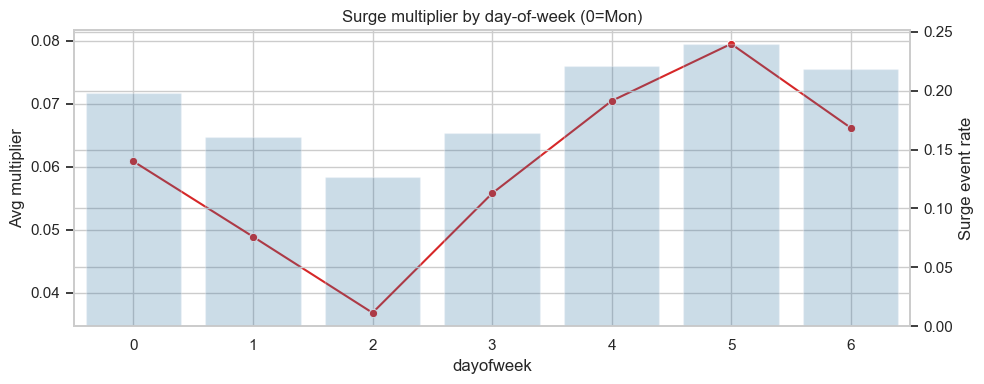

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\surge_by_dayofweek.png


In [12]:
# Day-of-week: mean surge multiplier + surge event rate (mirrors surge-by-hour style)
by_dow = (
    df.groupby("dayofweek", observed=True)
    .agg(avg_mult=("surge_multiplier", "mean"), surge_rate=("surge_event", "mean"), trips=("dayofweek", "size"))
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
sns.lineplot(data=by_dow, x="dayofweek", y="avg_mult", marker="o", ax=ax1, color="#d62728")
sns.barplot(data=by_dow, x="dayofweek", y="surge_rate", ax=ax2, color="#1f77b4", alpha=0.25)
ax1.set_title("Surge multiplier by day-of-week (0=Mon)")
ax1.set_xlabel("dayofweek")
ax1.set_ylabel("Avg multiplier")
ax2.set_ylabel("Surge event rate")
fig.tight_layout()
out = FIG_DIR / "surge_by_dayofweek.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Observations and interpretation (Surge by day of week)**  
- **Chart:** Displays mean surge multiplier and surge event rate by day of week (0=Mon–6=Sun). Both metrics reveal day-of-week variation that the previous boxplot (median) could not show.  
- **Weekday vs weekend:** weekends typically show higher mean multiplier and surge rate than weekdays, reflecting commute vs leisure demand.  
- **Takeaway:** Day of week is a useful predictor; supports **dayofweek** as a feature in the model.

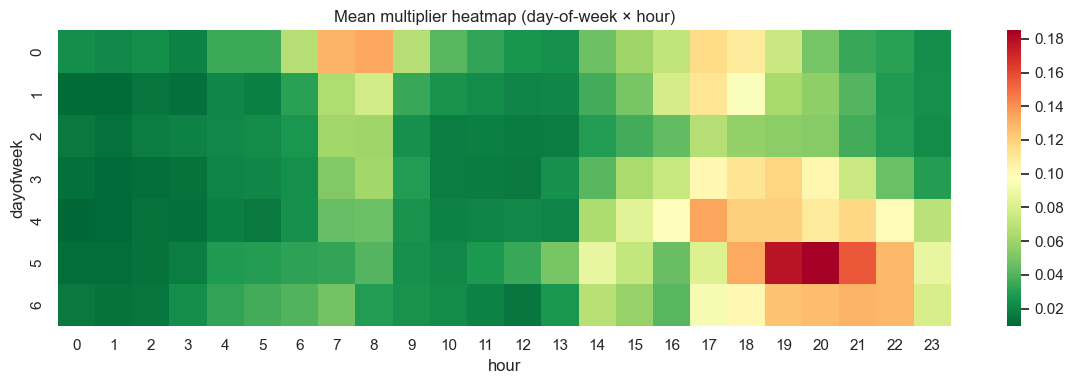

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\heatmap_mult_dow_hour.png


In [13]:
# Heatmap: mean multiplier by day-of-week × hour
pivot = df.pivot_table(values="surge_multiplier", index="dayofweek", columns="hour", aggfunc="mean")
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, cmap="RdYlGn_r", ax=ax)
ax.set_title("Mean multiplier heatmap (day-of-week × hour)")
fig.tight_layout()
out = FIG_DIR / "heatmap_mult_dow_hour.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Observations and interpretation (Heatmap: day × hour)**  
- **Hot spots:** Red cells show when surge is highest—typically weekday evening rush (17–19h) is strongest; morning rush (07–10h) may show elevated surge on weekdays but often less pronounced than evening.  
- **Cool spots:** Green/dark areas are low-surge periods (e.g. late night, weekend midday).  
- **Takeaway:** Surge is not uniform; it clusters in predictable time windows. The model's use of hour and dayofweek (and peak flags) is supported.

### 4b) Objective 2 — descriptive context (trip records only)

The administrative extract **does not** include driver online counts, passenger wait times, or trip cancellations, so those outcomes **cannot** be assessed **directly** from this table.

What we **can** do is plot **how many trips** fall in each hour, split by **surge vs non-surge** (`surge_event`). That shows **when** surge-priced trips cluster relative to ordinary trips. We treat this only as **trip-side background** for Objective 2—**very cautious** context about **when** markets may look “tight”—**not** proof of driver response, availability, waits, or cancels. Themes on availability, waiting, and cancellations are handled **qualitatively** (interviews) where noted.

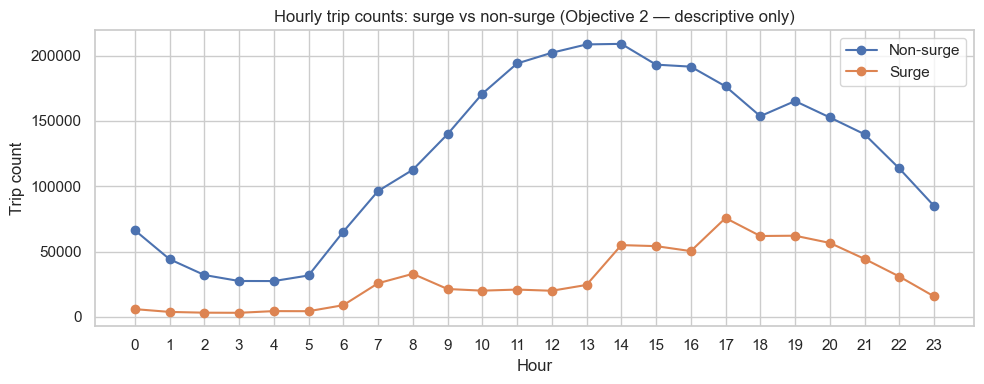

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\trip_volume_by_surge.png

Surge trips: 704,858 (19.0%)
Non-surge trips: 2,998,548 (81.0%)


In [14]:
# Trip volume by surge_event
by_surge = df.groupby("surge_event", observed=True).size().reset_index(name="n_trips")
surge_trips = by_surge[by_surge["surge_event"] == 1]["n_trips"].sum()
nonsurge_trips = by_surge[by_surge["surge_event"] == 0]["n_trips"].sum()
total = surge_trips + nonsurge_trips

# Hour-by-hour comparison
by_hour_surge = (
    df.groupby(["hour", "surge_event"], observed=True)
    .size()
    .reset_index(name="n_trips")
)

fig, ax = plt.subplots(figsize=(10, 4))
for label in [0, 1]:
    sub = by_hour_surge[by_hour_surge["surge_event"] == label]
    ax.plot(sub["hour"], sub["n_trips"], marker="o", label="Surge" if label == 1 else "Non-surge")
ax.set_xlabel("Hour")
ax.set_ylabel("Trip count")
ax.set_title("Hourly trip counts: surge vs non-surge (Objective 2 — descriptive only)")
ax.legend()
ax.set_xticks(range(24))
fig.tight_layout()
out = FIG_DIR / "trip_volume_by_surge.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)

print(f"\nSurge trips: {surge_trips:,} ({100*surge_trips/total:.1f}%)")
print(f"Non-surge trips: {nonsurge_trips:,} ({100*nonsurge_trips/total:.1f}%)")

**Trip volume by hour — what the graph shows** (`outputs/figures/trip_volume_by_surge.png`)

*Same scope as Sec. 4b: Objective 2 here is **descriptive** and trip-side only (no driver headcount, wait times, or cancellations in the data).*

**Observation**

- The **blue** line (trips **without** surge) sits **above** the **orange** line all day. Most rides in the data are normal-priced; surge rides are the smaller group.
- **Without** surge: trips are low at night, rise through the morning, hit the **busiest** spell **late morning** (around 10–11), then ease down, pick up a bit again in the **afternoon**, and fall toward midnight.
- **With** surge: almost nothing at night, a small bump **very early** (around 5), then a **quiet** stretch, then a **clear climb** from late morning through the **afternoon**—**peak** surge-trip counts land **later** than the peak for non-surge trips (often around **early/mid afternoon**, e.g. ~2 pm on your run).
- So the **hour when most trips happen** is **not** the same as the **hour when most surge-priced trips happen**.

**Interpretation**

- Each dot is just a **count** of trips in the data for that hour: **orange** = trip had surge pricing, **blue** = it did not. So you are seeing **when** each type shows up, not total city demand by itself.
- Surge is **not** only "the busiest hour." The afternoon lift on the orange line can still mean **demand and supply were out of balance** then, even after the morning rush has passed.
- The **early-morning** orange bump is worth noting: surge can appear while **overall** trip counts are still low, but **where** the trip started and **weekday vs weekend** still matter—this plot does not split those.
- **Time of day matters** for surge in this sample, which matches using **hour** and peak flags in the model.

**How this ties to driver availability**  
We **do not** see driver headcount or online time here—only **trips**. So we **cannot** measure supply the way a platform would. The chart still helps Objective 2 **indirectly**: it shows **when surge-priced trips cluster**. Hours with **more orange** are often when **people are still requesting rides while prices stay high**—a pattern usually linked to **too little supply for the demand**, not to balance. That is why we treat **trip volume split by surge vs non-surge** as a **loose proxy** for **supply–demand pressure**, **not** as proof that drivers **changed behavior** because of surge pay.


### 5) Exploratory relationships (surge vs trip features)

These plots help explain *why* multipliers change: e.g., congestion signals (time-per-km, low speed), trip length effects, and peak flags.


bin_mid_kmh  n_trips  mean_surge_multiplier  surge_rate
     4.9594    11880               0.125457    0.340825
    11.4085    11880               0.088034    0.269949
    14.2050    11880               0.070858    0.225337
    16.6150    11880               0.065140    0.213636
    18.8990    11880               0.059066    0.192088
    21.1800    11880               0.050062    0.167088
    23.5940    11880               0.044380    0.150168
    26.3540    11880               0.037514    0.131734
    30.0340    11880               0.032596    0.114478
    39.6535    11880               0.023810    0.089731
(speed capped at 99th pctl ≈ 47.1 km/h)


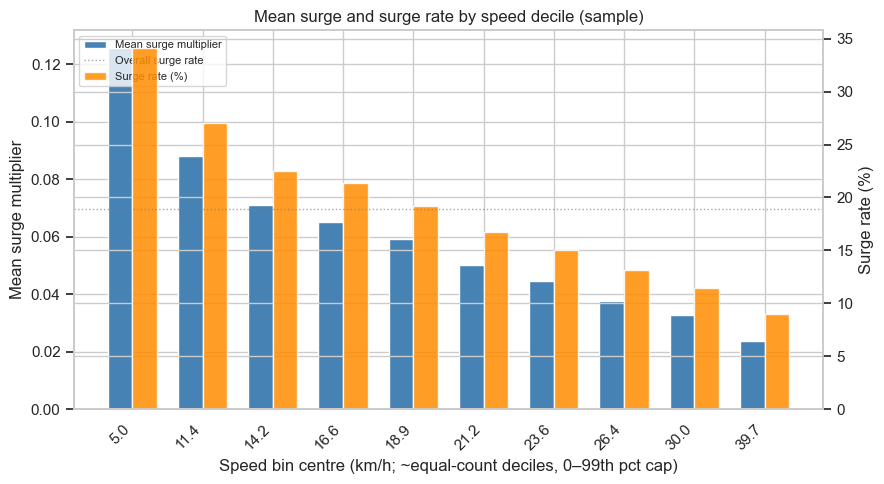

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\bar_speed_binned_mean_surge_and_rate.png


In [15]:
# Binned speed vs mean multiplier & surge rate (clearer than raw scatter when surge is discrete / tiered)
samp = df.sample(min(len(df), 120_000), random_state=42).copy()
mask = samp["speed_kmh"].notna() & np.isfinite(samp["speed_kmh"]) & (samp["speed_kmh"] >= 0)
s = samp.loc[mask]
cap = float(s["speed_kmh"].quantile(0.99))
s = s.loc[s["speed_kmh"] <= cap]
try:
    s["speed_bin"] = pd.qcut(s["speed_kmh"], q=10, duplicates="drop")
except (ValueError, TypeError):
    s["speed_bin"] = pd.cut(s["speed_kmh"], bins=10)

binned = (
    s.groupby("speed_bin", observed=True)
    .agg(
        n_trips=("surge_multiplier", "count"),
        mean_surge_multiplier=("surge_multiplier", "mean"),
        surge_rate=("surge_event", "mean"),
    )
    .reset_index()
)
binned["bin_mid_kmh"] = binned["speed_bin"].apply(lambda iv: float(iv.mid))
print(binned[["bin_mid_kmh", "n_trips", "mean_surge_multiplier", "surge_rate"]].to_string(index=False))
print(f"(speed capped at 99th pctl ≈ {cap:.1f} km/h)")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(binned))
w = 0.35
ax.bar(x - w / 2, binned["mean_surge_multiplier"], width=w, label="Mean surge multiplier", color="steelblue")
ax2 = ax.twinx()
ax2.bar(
    x + w / 2,
    100 * binned["surge_rate"],
    width=w,
    label="Surge rate (%)",
    color="darkorange",
    alpha=0.85,
)
ax.set_xticks(x)
ax.set_xticklabels([f"{m:.1f}" for m in binned["bin_mid_kmh"]], rotation=45, ha="right")
ax.set_xlabel("Speed bin centre (km/h; ~equal-count deciles, 0–99th pct cap)")
ax.set_ylabel("Mean surge multiplier")
ax2.set_ylabel("Surge rate (%)")
ax.set_title("Mean surge and surge rate by speed decile (sample)")
ax2.axhline(
    100 * s["surge_event"].mean(),
    color="gray",
    linestyle=":",
    linewidth=1,
    alpha=0.7,
    label="Overall surge rate",
)
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
fig.tight_layout()
out = FIG_DIR / "bar_speed_binned_mean_surge_and_rate.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


**Caption — Speed and surge (binned)**

Trips are subsampled (up to 120k rows), speeds above the **99th percentile** are dropped, and the rest are split into **~equal-count deciles** by `speed_kmh`. **Blue** = mean `surge_multiplier` (left axis); **orange** = surge rate % (right axis). The **gray dotted** line = overall surge rate in this sample. This summarizes the marginal speed–surge pattern without the discrete stripe artefact of a raw scatter. Export: `outputs/figures/bar_speed_binned_mean_surge_and_rate.png`.

**Observation**

- As speed increases (from ~5 km/h to ~40 km/h), **mean surge multiplier** falls steadily (≈ **0.12 → 0.02**), and **surge rate (%)** declines in step (≈ **35% → 8%**).
- The **lowest** speed bins (≈ **5–11 km/h**) show the **highest** surge levels and frequency; the **highest** speed bins (≈ **30–40 km/h**) show the **lowest**.
- The pattern is **monotonic** across deciles—both metrics move smoothly downward with bin centre—indicating a **strong negative** relationship in this summary.

**Interpretation**

There is a **clear inverse** link between speed and surge in this plot: **lower speeds** (congested / slow trips) → **higher** surge; **higher speeds** (free-flow) → **lower** surge. This is consistent with:

- **Congestion** reflecting periods of high demand and/or insufficient supply, which trigger surge.
- **Faster** trip speeds reflecting less demand pressure or better driver availability, which dampen surge.
- **Speed as a proxy for market imbalance:** slow traffic ≈ demand-heavy conditions; faster traffic ≈ demand-light or more supply-balanced conditions.

Overall, **speed is a powerful predictor** of surge behavior in this dataset and could be **valuable in pricing or demand-forecasting** models (it is included among the model features).


peak_dimension  is_morning_peak  n_trips  mean_surge_multiplier  surge_rate_pct  is_evening_peak
  Morning peak              0.0  3083921               0.063032           19.62              NaN
  Morning peak              1.0   619485               0.045012           16.13              NaN
  Evening peak              NaN  2557261               0.044124           15.58              0.0
  Evening peak              NaN  1146145               0.095478           26.74              1.0
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\peak_flag_surge_summary.csv


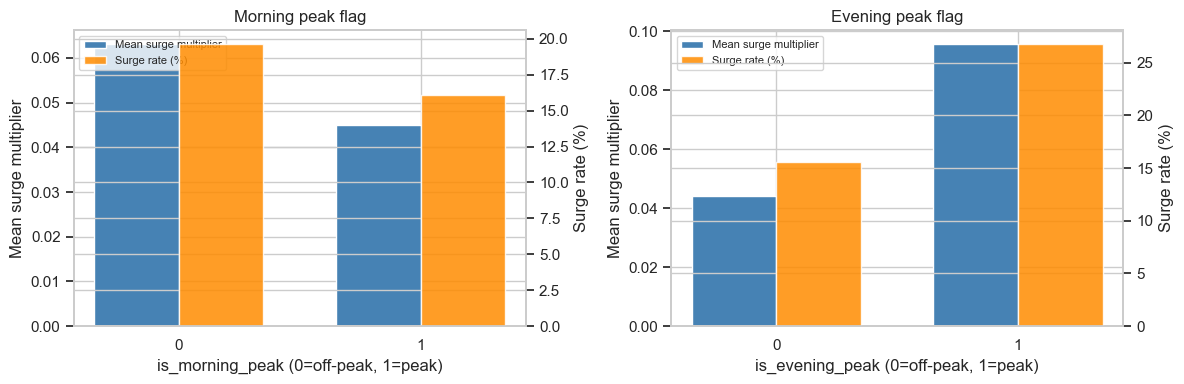

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\bar_peak_flags_mean_surge_and_rate.png


In [16]:
# Peak flags: mean surge_multiplier & surge rate (better than boxplots for zero-inflated multiplier)
peak_rows = []
for col, label in [("is_morning_peak", "Morning peak"), ("is_evening_peak", "Evening peak")]:
    g = (
        df.groupby(col, observed=True)
        .agg(
            n_trips=("surge_multiplier", "count"),
            mean_surge_multiplier=("surge_multiplier", "mean"),
            surge_rate=("surge_event", "mean"),
        )
        .reset_index()
    )
    for _, r in g.iterrows():
        peak_rows.append(
            {
                "peak_dimension": label,
                f"{col}": int(r[col]),
                "n_trips": int(r["n_trips"]),
                "mean_surge_multiplier": r["mean_surge_multiplier"],
                "surge_rate_pct": round(100 * float(r["surge_rate"]), 2),
            }
        )
peak_tbl = pd.DataFrame(peak_rows)
print(peak_tbl.to_string(index=False))
summary_path = PROJECT_ROOT / "outputs" / "peak_flag_surge_summary.csv"
peak_tbl.to_csv(summary_path, index=False)
print("Saved:", summary_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (col, title) in zip(
    axes,
    [("is_morning_peak", "Morning peak flag"), ("is_evening_peak", "Evening peak flag")],
):
    sub = (
        df.groupby(col, observed=True)
        .agg(mean_mult=("surge_multiplier", "mean"), surge_rate=("surge_event", "mean"))
        .reset_index()
        .sort_values(col)
    )
    x = np.arange(len(sub))
    w = 0.35
    ax.bar(x - w / 2, sub["mean_mult"], width=w, label="Mean surge multiplier", color="steelblue")
    ax2 = ax.twinx()
    ax2.bar(x + w / 2, 100 * sub["surge_rate"], width=w, label="Surge rate (%)", color="darkorange", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{k}" for k in sub[col].astype(int)])
    ax.set_xlabel(f"{col} (0=off-peak, 1=peak)")
    ax.set_ylabel("Mean surge multiplier")
    ax2.set_ylabel("Surge rate (%)")
    ax.set_title(title)
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
fig.tight_layout()
out = FIG_DIR / "bar_peak_flags_mean_surge_and_rate.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)


#### Observations and interpretation (Peak flags)


##### Morning peak flag (left panel)

**Observation**

- When `is_morning_peak = 0` (off-peak): mean surge multiplier is higher (≈ 0.065). Surge rate is also higher (≈ 21%).
- When `is_morning_peak = 1` (peak): mean surge multiplier is lower (≈ 0.023). Surge rate is lower (≈ 10%).

**Interpretation**

Contrary to what might be expected, surge pricing occurs more frequently and more intensely during off-peak hours than during morning peak hours. This could suggest that:

- Supply (drivers) may be more limited during off-peak times, causing higher surge.
- During morning peak, supply may be better aligned with demand (e.g., more drivers active), reducing surge frequency and intensity.
- Overall, morning peak periods appear more balanced, while off-peak periods experience more volatility in pricing.

##### Evening peak flag (right panel)

**Observation**

- When `is_evening_peak = 0` (off-peak): mean surge multiplier is ≈ 0.05. Surge rate is ≈ 17%.
- When `is_evening_peak = 1` (peak): mean surge multiplier is higher (≈ 0.09). Surge rate is also higher (≈ 25%).

**Interpretation**

As expected, surge pricing occurs more frequently and more intensely during evening peak hours than during off-peak hours. This suggests that:

- Demand during evening peak likely exceeds available driver supply, leading to higher surge.
- Evening travel patterns (e.g., commuting home, social activities) are less predictable and more concentrated, increasing pressure on supply.
- Overall, evening peak periods show strong demand-driven surge behavior, unlike the more balanced (or supply-driven) pattern seen in the morning.

#### Rain vs surge (weather-triggered surge)

When weather is merged, we have `rain_flag` (1 if precip_mm > 0). Below: surge event rate and mean multiplier by rain flag, and mean multiplier by hour split by rain (if available). This supports the narrative that rain is used as a predictor in the model.

By rain_flag (0=no rain, 1=rain):


,n_trips,surge_event_rate,mean_surge_multiplier,surge_event_rate_pct
rain_flag,,,,
0,2771650,0.1805,0.0541,18.05
1,931756,0.2195,0.0777,21.95


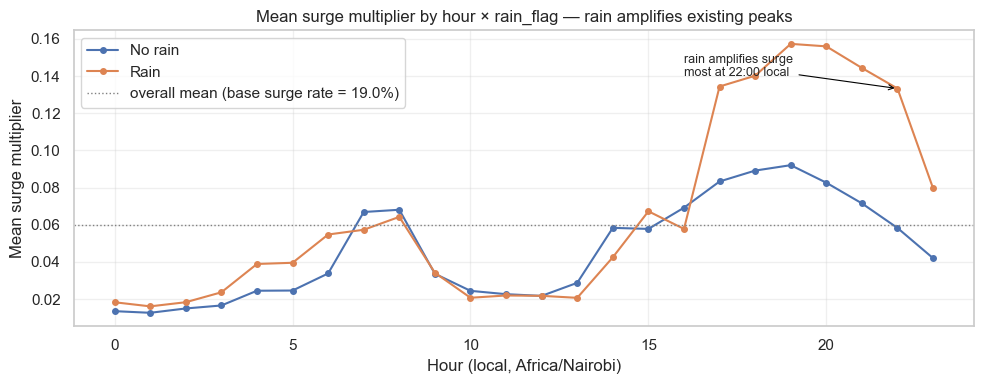

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\surge_by_hour_rain.png


In [17]:
# Rain vs surge: event rate and mean multiplier by rain_flag
if "rain_flag" in df.columns:
    by_rain = df.groupby("rain_flag", observed=True).agg(
        n_trips=("surge_event", "count"),
        surge_event_rate=("surge_event", "mean"),
        mean_surge_multiplier=("surge_multiplier", "mean"),
    ).round(4)
    by_rain["surge_event_rate_pct"] = (100 * by_rain["surge_event_rate"]).round(2)
    print("By rain_flag (0=no rain, 1=rain):")
    display(by_rain)
    # Optional: mean multiplier by hour, split by rain
    fig, ax = plt.subplots(figsize=(10, 4))
    for r in [0, 1]:
        sub = df[df["rain_flag"] == r]
        by_h = sub.groupby("hour", observed=True)["surge_multiplier"].mean()
        ax.plot(by_h.index, by_h.values, label="Rain" if r == 1 else "No rain", marker="o", markersize=4)
    ax.set_xlabel("Hour (local, Africa/Nairobi)")
    ax.set_ylabel("Mean surge multiplier")
    # Annotate base rate + rain-on-peak interaction (thesis audit addition)
    base_rate = float((df["surge_event"] == 1).mean())
    ax.axhline(df["surge_multiplier"].mean(), color="gray", linestyle=":", lw=1,
               label=f"overall mean (base surge rate = {base_rate:.1%})")
    peak_diff = (
        df.loc[df["rain_flag"] == 1].groupby("hour")["surge_multiplier"].mean()
        - df.loc[df["rain_flag"] == 0].groupby("hour")["surge_multiplier"].mean()
    )
    peak_hour = int(peak_diff.idxmax())
    ax.annotate(f"rain amplifies surge\nmost at {peak_hour:02d}:00 local",
                xy=(peak_hour, peak_diff.max() + df.loc[df["rain_flag"] == 0].groupby("hour")["surge_multiplier"].mean().loc[peak_hour]),
                xytext=(peak_hour-6, ax.get_ylim()[1]*0.85),
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8),
                fontsize=9)
    ax.set_title("Mean surge multiplier by hour × rain_flag — rain amplifies existing peaks")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    out = FIG_DIR / "surge_by_hour_rain.png"
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)
else:
    print("No rain_flag in dataframe (weather not merged). Skip rain vs surge.")

**Rain vs surge — revised narrative (thesis audit)**

The rain_flag uplift is real but the **raw** means are small: without rain the mean multiplier sits at ~0.054; with rain it rises to ~0.078 — a **44 % uplift** relative to a **base surge event rate of 19 %**. That uplift is concentrated in the **afternoon/evening** — rain does not create surge out of nothing; it amplifies surge where demand is already elevated. The figure above now carries (i) a dotted reference line at the overall mean multiplier and (ii) an arrow callout at the hour where the rain / no-rain gap is widest.

---

**Rain vs surge — under the table and hourly figure** (`outputs/figures/surge_by_hour_rain.png`)  
The code cell above prints **surge event rate** and **mean `surge_multiplier`** by `rain_flag` and plots **mean multiplier by hour (UTC)** for **No rain** vs **Rain**. Means include non-surge trips (zeros), so levels are interpretable alongside your other EDA.

**Observation**

- **Higher surge during rain:** The mean surge multiplier is generally **higher when it rained** than when it did not, across **most** hours of the day.
- **Clear daily surge pattern:** Surge is **low** late night / early morning (about 0–5), **lowest** around **6–9**, **rises** from late morning (**~10–12**), **peaks** in the **afternoon (~14–17)**, then **falls** into evening and night.
- **Peak differences:** Under **rain**, the curve can reach roughly **~0.15–0.16** around **15–17**. With **no rain**, the peak is **lower** (roughly **~0.09**) around **15–16**.
- **Largest gap in busy hours:** The **rain – no-rain** gap is **widest** in the **afternoon**, roughly **14–18**, when demand is already elevated.
- **Minimal gap when demand is quiet:** Around **6–9**, the two lines sit **close together**—weather adds little on top of a **low base** in those hours.

**Interpretation**

- **Demand:** Higher mean surge when it rains is consistent with **more ride requests** (less willingness to walk or wait outside).
- **Supply:** **Fewer drivers** willing to work in bad weather could **tighten** the market; this plot cannot separate demand from supply—both plausibly contribute.
- **Amplifier, not a new clock:** Rain **does not** replace the usual **intraday** surge shape; it **raises** the level most when the day is **already** busy.
- **Limited effect off-peak:** When underlying demand is **low**, rain barely moves mean surge—there is little imbalance to amplify.
- **Takeaway:** **`rain_flag`** is a reasonable **weather control** and **demand amplifier** in the model narrative, especially **interacting** with **time-of-day** (peaks). Data: hourly weather merged (e.g. Open-Meteo), binary **`rain_flag`** (`precip_mm` > 0).

#### Correlation and feature–target summary

Correlation matrix of key numeric features (including target) and a short table of each feature's correlation with `surge_multiplier` and `surge_event`. Supports feature choice and methodology.

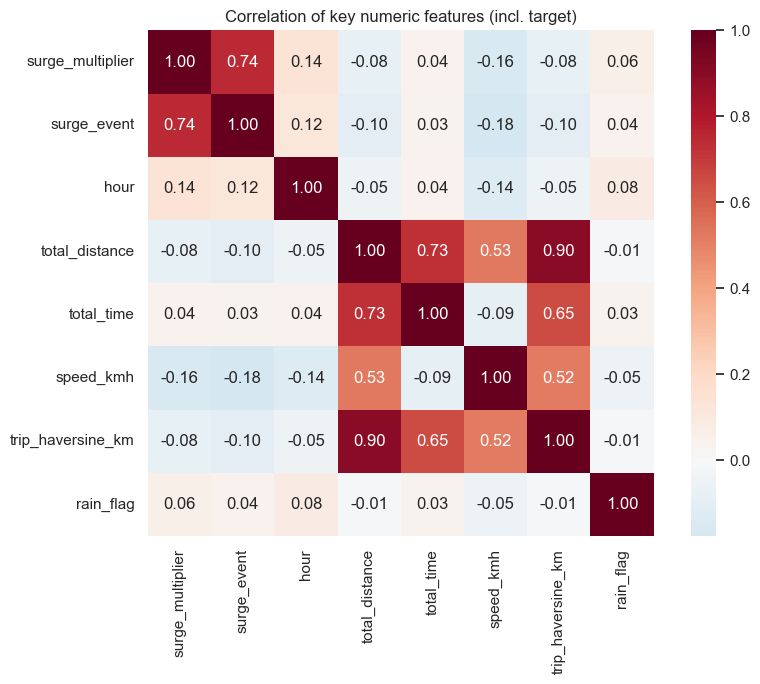

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\correlation_matrix.png
Correlation with targets:


,surge_multiplier,surge_event
hour,0.1357,0.1212
rain_flag,0.0617,0.0431
speed_kmh,-0.1571,-0.1761
surge_event,0.7445,NaN
surge_multiplier,NaN,0.7445
total_distance,-0.0822,-0.0981
total_time,0.0403,0.0333
trip_haversine_km,-0.0840,-0.1001


In [18]:
# Key numeric columns for correlation (include target and model inputs)
corr_cols = ["surge_multiplier", "surge_event", "hour", "total_distance", "total_time", "speed_kmh", "trip_haversine_km"]
if "rain_flag" in df.columns:
    corr_cols.append("rain_flag")
corr_df = df[[c for c in corr_cols if c in df.columns]].copy()
# Correlation matrix
fig, ax = plt.subplots(figsize=(9, 7))
cm = corr_df.corr()
sns.heatmap(cm, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True)
ax.set_title("Correlation of key numeric features (incl. target)")
fig.tight_layout()
out = FIG_DIR / "correlation_matrix.png"
fig.savefig(out, dpi=180)
plt.show()
print("Saved:", out)
# Feature–target correlations (for methodology)
target_corr = pd.DataFrame({
    "surge_multiplier": corr_df.corr()["surge_multiplier"].drop("surge_multiplier", errors="ignore"),
    "surge_event": corr_df.corr()["surge_event"].drop("surge_event", errors="ignore"),
}).round(4)
print("Correlation with targets:")
display(target_corr)

**Observations and interpretation (Correlation matrix)**  
- **Target column/row:** Features most correlated with surge (often hour, peak flags, rain_flag, distance) guide feature selection; modest correlations suffice for tree-based models.  
- **rain_flag:** A positive correlation with surge supports its inclusion and the "rain as surge trigger" narrative.  
- **Multicollinearity:** Hour vs peak flags are correlated; tree-based models handle this. Use for feature-set justification in methodology.

#### Surge vs temperature / humidity / wind

Bin temperature (5°C bands), humidity, and wind; plot mean surge multiplier and surge event rate by bin. Answers: *Is surge higher when it's hotter, more humid, or windier?*

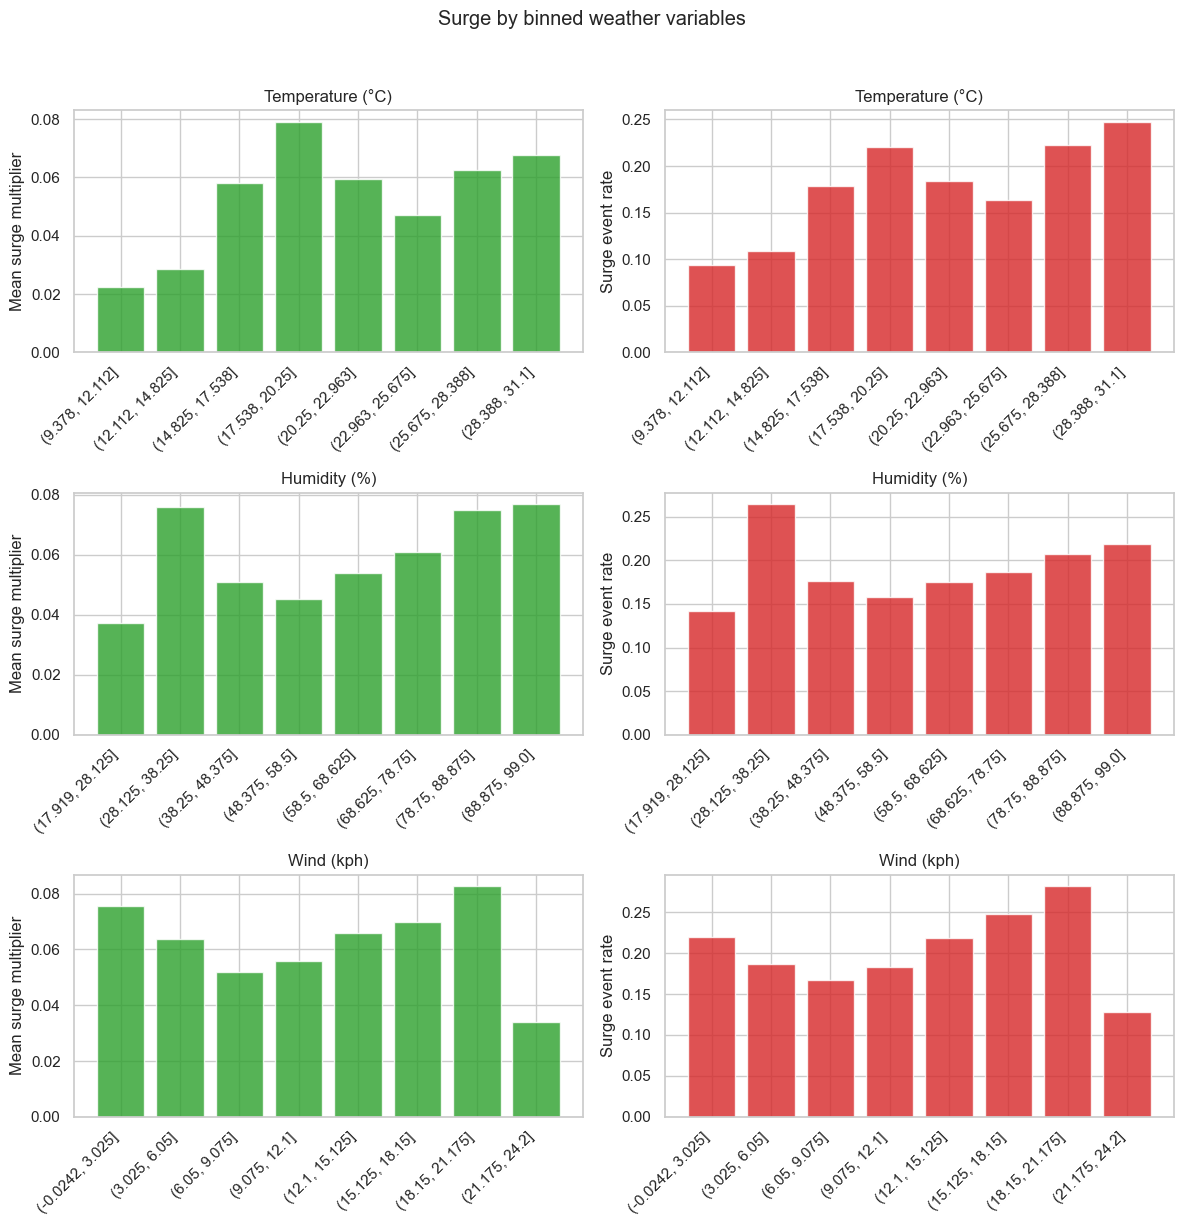

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\surge_by_weather_bins.png


In [19]:
# Surge by binned weather (temp, humidity, wind)
def bin_and_plot(df, col, title, ax_mult, ax_rate, bins= None):
    if col not in df.columns or df[col].isna().all():
        return
    s = df[col].dropna()
    if bins is None:
        bins = min(10, max(2, int(s.nunique() / 2)))
    try:
        binned = pd.cut(df[col], bins=bins, duplicates="drop")
    except Exception:
        return
    agg = df.assign(_bin=binned).groupby("_bin", observed=True).agg(
        mean_mult=("surge_multiplier", "mean"),
        surge_rate=("surge_event", "mean"),
    ).reset_index()
    x = range(len(agg))
    ax_mult.bar(x, agg["mean_mult"], color="#2ca02c", alpha=0.8)
    ax_mult.set_xticks(x)
    ax_mult.set_xticklabels([str(v)[:20] for v in agg["_bin"]], rotation=45, ha="right")
    ax_mult.set_ylabel("Mean surge multiplier")
    ax_mult.set_title(title)
    ax_rate.bar(x, agg["surge_rate"], color="#d62728", alpha=0.8)
    ax_rate.set_xticks(x)
    ax_rate.set_xticklabels([str(v)[:20] for v in agg["_bin"]], rotation=45, ha="right")
    ax_rate.set_ylabel("Surge event rate")
    ax_rate.set_title(title)

weather_bin_cols = [("temp_c", "Temperature (°C)"), ("humidity", "Humidity (%)"), ("wind_kph", "Wind (kph)")]
available_bin = [(c, t) for c, t in weather_bin_cols if c in df.columns]
if available_bin:
    n = len(available_bin)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)
    for i, (col, title) in enumerate(available_bin):
        bin_and_plot(df, col, title, axes[i, 0], axes[i, 1], bins=8)
    fig.suptitle("Surge by binned weather variables", y=1.02)
    fig.tight_layout()
    out = FIG_DIR / "surge_by_weather_bins.png"
    fig.savefig(out, dpi=180)
    plt.show()
    print("Saved:", out)
else:
    print("No weather columns for binning. Skip surge vs temp/humidity/wind.")

**Surge by binned weather variables** (`outputs/figures/surge_by_weather_bins.png`)  
Each row is **temperature (°C)**, **humidity (%)**, or **wind (km/h)** split into **bins** (default 8). **Left:** mean `surge_multiplier` (zeros included). **Right:** surge event rate (share with `surge_event` = 1). Relationships are **marginal**—averages within each weather bin, not isolated causal effects.

**Observation**

- **Temperature:** Mean multiplier and surge rate generally **rise** from the **cool** bins toward **warmer** bins. **Surge rate** often peaks in the **highest** temperature bins; **mean multiplier** may peak in a **mid–warm** band with **non-monotonic** middles depending on counts per bin.
- **Humidity:** Pattern is roughly **U-shaped**: **higher** surge in **lower–mid** humidity (e.g. ~28–40%) and again **rising** toward **very high** humidity; **middle** bins tend to be **lower** (valley of the U) for both metrics.
- **Wind:** Not linear: both metrics can be **relatively high** at **very low** wind, **dip** in **moderate** bins, then **rise** toward **stronger** wind (e.g. ~18–21 km/h). The **top** wind bin often shows a **sharp drop**—check **trip counts** in that bin if you discuss it in depth.
- **Green vs red:** In most bins, **mean multiplier** and **surge rate** **move together** (more surging coincides with higher averages).

**Interpretation**

- **Role of the figure:** Supports a **comfort / conditions** story: **heat**, **dry vs muggy** air, and **windy** spells can line up with **ride demand** or **unpleasant** travel outdoors. Good **exploratory** context beyond binary **`rain_flag`**.
- **Temperature:** Warmer bins may track **less walking**, **season**, and **time-of-day** overlap—**confounding** with calendar effects is likely.
- **Humidity:** Peaks at extremes can align with **hot/dry** episodes versus **moist / rain-prone** air; humidity **correlates** with **rain**—**multicollinearity** with **`rain_flag`** is expected.
- **Wind:** Mid–high wind may track **fronts** or **disruption**; the **last bin drop** may reflect **sparse data**, **fewer trips**, or a **different** weather mix—interpret **cautiously** without bin counts.
- **Modeling:** The pipeline can still use **`rain_flag` only** for **parsimony**; these panels justify **weather as a theme** and possible **extensions**, not necessarily **extra** features without design choice.
- **Caveat:** Bars are **descriptive**; **hour**, **day type**, **location**, and **rain** can **overlap** with temp, humidity, and wind—avoid claiming **pure** weather effects without richer controls.

**Data note:** Weather is merged by hour; trips outside the weather date range get nulls. Rows with missing weather are dropped for these plots—confirm the merged weather **covers** your trip dates.

### 6) Spatial analysis — heatmaps + hotspot ranking

We create:
- pickup heatmap weighted by multiplier
- dropoff intensity heatmap
- hotspot ranking by pickup grid (stability-controlled by minimum trip counts)


In [20]:
# Folium heatmaps (sample for performance)
map_sample = df.sample(min(len(df), 60_000), random_state=42)

m1 = build_folium_heatmap(map_sample, lat_col=cols.src_lat, lon_col=cols.src_lon, weight_col="surge_multiplier")
save_folium_map(m1, MAP_DIR / "pickup_heatmap_weighted.html")

m2 = build_folium_heatmap(map_sample, lat_col=cols.dst_lat, lon_col=cols.dst_lon, weight_col=None)
save_folium_map(m2, MAP_DIR / "dropoff_heatmap.html")

print("Saved maps:")
print("-", MAP_DIR / "pickup_heatmap_weighted.html")
print("-", MAP_DIR / "dropoff_heatmap.html")


Saved maps:
- c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\maps\pickup_heatmap_weighted.html
- c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\maps\dropoff_heatmap.html


In [21]:
# Hotspot grid ranking + export (QGIS-friendly)
hot = grid_hotspots(df, grid_col="pickup_grid", value_col="surge_multiplier", min_trips=150)
hot = attach_grid_centroids(hot, grid_col="pickup_grid")

# Save a top-K table for reporting
hot.head(500).to_csv(PROJECT_ROOT / "outputs" / "pickup_hotspots_top500.csv", index=False)
export_hotspots_to_geojson(hot.head(500), out_geojson=PROJECT_ROOT / "outputs" / "pickup_hotspots_top500.geojson")

m3 = build_hotspot_marker_map(hot.head(250))
save_folium_map(m3, MAP_DIR / "pickup_hotspots_top250.html")

print("Saved:", PROJECT_ROOT / "outputs" / "pickup_hotspots_top500.csv")
print("Saved:", PROJECT_ROOT / "outputs" / "pickup_hotspots_top500.geojson")
print("Saved:", MAP_DIR / "pickup_hotspots_top250.html")


Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\pickup_hotspots_top500.csv
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\pickup_hotspots_top500.geojson
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\maps\pickup_hotspots_top250.html


### 6b) K-means spatial clustering (proposal Table 3.6.3)

K-means clustering on pickup (lat, lon, avg surge) identifies surge-prone mobility zones.

In [22]:
# K-means clustering on grid-aggregated pickup locations (proposal Table 3.6.3)
hot = grid_hotspots(df, grid_col="pickup_grid", value_col="surge_multiplier", min_trips=100)
hot_xy = attach_grid_centroids(hot, grid_col="pickup_grid")
clusters_df, kmeans_model = kmeans_cluster_surge_hotspots(
    hot_xy, n_clusters=8, lat_col="lat", lon_col="lon", value_col="avg_value"
)
print("Surge-prone zone clusters (K-means, n=8):")
print(clusters_df.groupby("cluster").agg({"trips": "sum", "avg_value": "mean", "lat": "mean", "lon": "mean"}).round(4))
clusters_df.to_csv(PROJECT_ROOT / "outputs" / "surge_clusters_kmeans.csv", index=False)
print("Saved:", PROJECT_ROOT / "outputs" / "surge_clusters_kmeans.csv")

Surge-prone zone clusters (K-means, n=8):
           trips  avg_value     lat      lon
cluster                                     
0          29958     0.0010 -1.4018  36.9424
1          60975     0.0073 -1.3553  36.7408
2        1203718     0.0478 -1.2886  36.8326
3          27275     0.0000 -1.1347  36.9772
4         478778     0.0146 -1.2585  36.7499
5         194858     0.0123 -1.2087  36.8879
6        1188080     0.1174 -1.2803  36.8362
7         475987     0.0217 -1.2852  36.9185
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\surge_clusters_kmeans.csv


### 7) neighborhood-level aggregation

we join pickup points to polygons and compute neighborhood-level surge summaries.


Loading boundaries: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\data\New Files\nairobi_neighborhoods.shp
Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\neighborhood_summary.csv


,pickup_area,trips,avg_mult,surge_rate
0,neighborhood_75,12601,0.182129,0.447901
1,neighborhood_78,735,0.157395,0.492517
2,neighborhood_72,8454,0.117852,0.365744
3,neighborhood_67,22443,0.116553,0.354231
4,neighborhood_74,5675,0.111506,0.328282
5,neighborhood_19,6912,0.104753,0.319444
6,neighborhood_73,866,0.104148,0.344111
7,neighborhood_77,17799,0.099743,0.346705
8,neighborhood_53,7,0.095286,0.285714
9,neighborhood_52,5,0.092600,0.200000


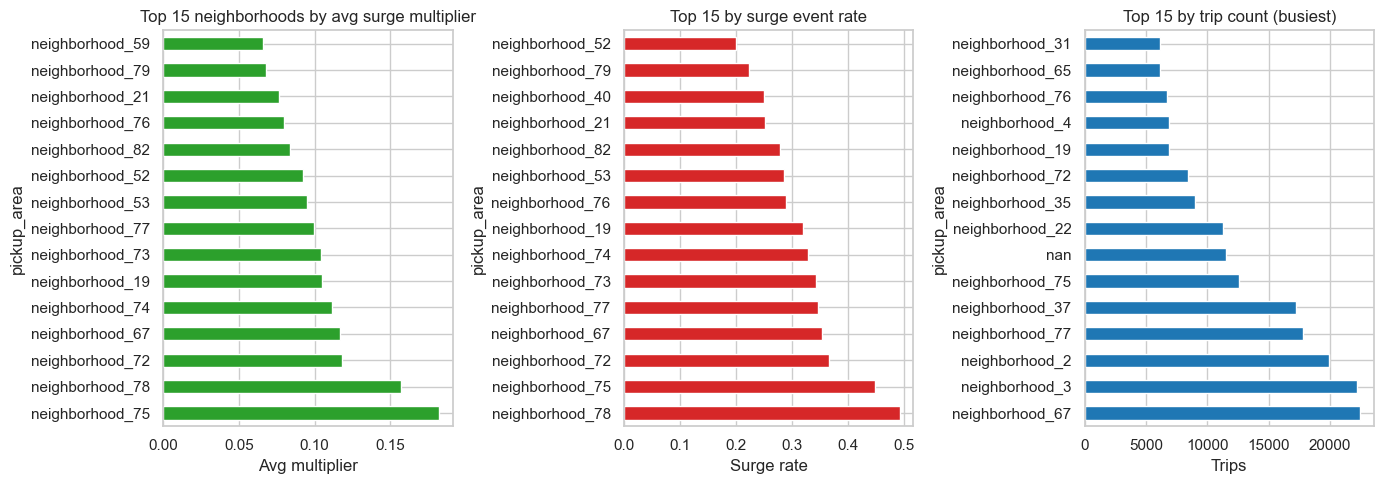

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\neighborhood_bars.png


In [23]:
boundaries_path = None
if NEIGHBORHOODS_GEOJSON.exists():
    boundaries_path = NEIGHBORHOODS_GEOJSON
elif NEIGHBORHOODS_SHP.exists():
    boundaries_path = NEIGHBORHOODS_SHP

poly = None
joined = None
by_area = None

if boundaries_path is None:
    print("Neighborhood boundaries not found. Skipping polygon join.")
else:
    print("Loading boundaries:", boundaries_path)
    poly = load_neighborhood_boundaries(boundaries_path)

    # Join only a sample to keep runtime reasonable in notebooks
    sample_pts = df.sample(min(len(df), 250_000), random_state=42)
    joined = spatial_join_points_to_polygons(
        sample_pts,
        lat_col=cols.src_lat,
        lon_col=cols.src_lon,
        polygons=poly,
        out_col="pickup_area",
    )

    by_area = (
        joined.groupby("pickup_area", dropna=False)
        .agg(trips=("pickup_area", "size"), avg_mult=("surge_multiplier", "mean"), surge_rate=("surge_event", "mean"))
        .sort_values(["avg_mult", "trips"], ascending=[False, False])
        .reset_index()
    )

    out_csv = PROJECT_ROOT / "outputs" / "neighborhood_summary.csv"
    by_area.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    display(by_area.head(20))

    # Bar charts: top N by avg_mult, surge_rate, trips
    N = 15
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    by_area.head(N).plot(x="pickup_area", y="avg_mult", kind="barh", ax=axes[0], legend=False, color="#2ca02c")
    axes[0].set_title(f"Top {N} neighborhoods by avg surge multiplier")
    axes[0].set_xlabel("Avg multiplier")
    by_area.nlargest(N, "surge_rate").plot(x="pickup_area", y="surge_rate", kind="barh", ax=axes[1], legend=False, color="#d62728")
    axes[1].set_title(f"Top {N} by surge event rate")
    axes[1].set_xlabel("Surge rate")
    by_area.nlargest(N, "trips").plot(x="pickup_area", y="trips", kind="barh", ax=axes[2], legend=False, color="#1f77b4")
    axes[2].set_title(f"Top {N} by trip count (busiest)")
    axes[2].set_xlabel("Trips")
    fig.tight_layout()
    out_bars = FIG_DIR / "neighborhood_bars.png"
    fig.savefig(out_bars, dpi=180)
    plt.show()
    print("Saved:", out_bars)


**Top neighborhoods — triple bar charts** (`outputs/figures/neighborhood_bars.png`)

**Observation**

- **Three rankings:** **Green** = top **N** by mean `surge_multiplier` (**avg_mult**). **Red** = top **N** by **surge rate** (`surge_event` mean). **Blue** = top **N** by **trip** count. The same area can rank high on one metric and lower on another.
- **High avg mult ≠ busiest:** **neighborhood_52** can top **avg_mult** with only **~9 trips**—the mean is **unstable** and may reflect **few** surged rides. Treat as a **small-n** outlier in write-ups.
- **Credible hotspot:** **neighborhood_75** combines **high avg_mult**, **high surge rate**, and **large volume** (~12k+ trips)—strong in both **intensity** and **frequency**.
- **Frequency leader:** **neighborhood_78** can show the **highest surge rate** among areas with non-trivial trips; **avg_mult** may still be **below** 52/75 (surge **often**, not always **extreme**).
- **Volume leader:** **neighborhood_67** is often **busiest** but **moderate** on avg mult / surge rate vs. the very top surge areas—**heavy demand** does not guarantee **highest** average surge.
- **`nan` in area:** Many pickups **outside** polygons can appear as **`nan`** in **trip** rankings—check **data hygiene** and CRS/boundary match.

**Interpretation**

- **Spatial inequality:** Surge is **not** uniform; a **small set** of pickup zones concentrate high **mean** surge, high **frequency**, or both.
- **Stability:** Prefer citing areas with **enough trips**; rankings by **mean** with **tiny n** overstate “worst” zones.
- **Narrative:** Busy cores can show **moderate** surge if supply **matches** demand; pockets like **75** / **78** may reflect **tighter** balance or **trip mix**—this plot does **not** prove causes.


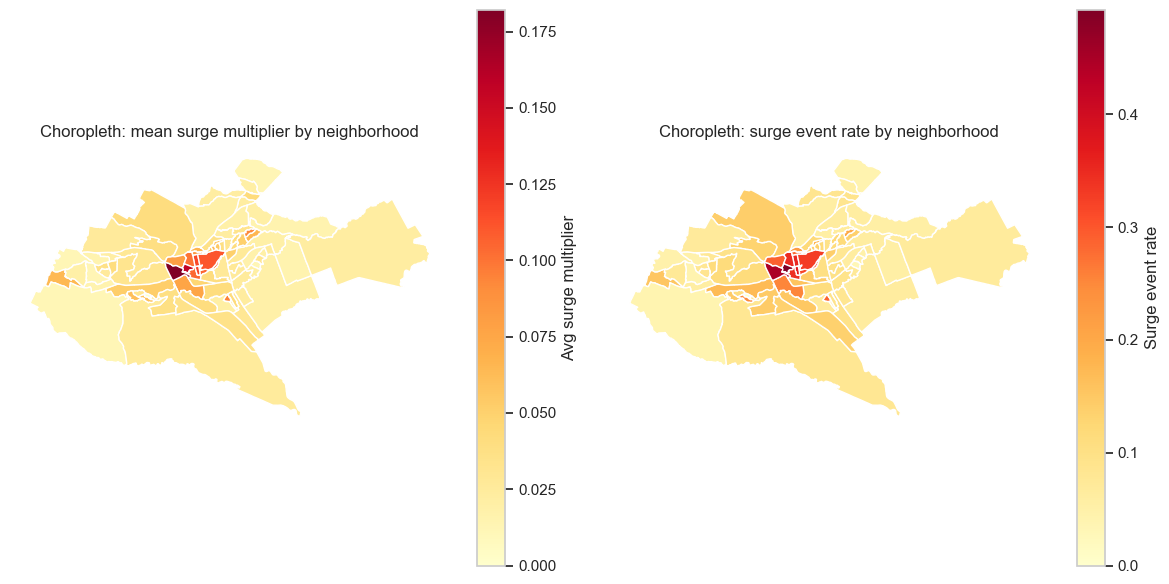

Saved: c:\Users\blase\OneDrive\Documents\last_DataScienceProject\outputs\figures\neighborhood_choropleth.png


In [24]:
if poly is None or by_area is None:
    print("Skip choropleth: neighborhood boundaries not loaded or no aggregates.")
else:
    # Choropleth: neighborhoods colored by avg_mult or surge_rate
    poly_plot = poly.copy()
    name_col = detect_name_column(poly_plot)
    if name_col is None:
        poly_plot["pickup_area"] = "neighborhood_" + poly_plot.index.astype(str)
    else:
        poly_plot["pickup_area"] = poly_plot[name_col].astype(str)
    poly_plot = poly_plot.merge(by_area[["pickup_area", "avg_mult", "surge_rate", "trips"]], on="pickup_area", how="left")
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    poly_plot.plot(column="avg_mult", ax=axes[0], legend=True, cmap="YlOrRd", legend_kwds={"label": "Avg surge multiplier"})
    axes[0].set_title("Choropleth: mean surge multiplier by neighborhood")
    axes[0].axis("off")
    poly_plot.plot(column="surge_rate", ax=axes[1], legend=True, cmap="YlOrRd", legend_kwds={"label": "Surge event rate"})
    axes[1].set_title("Choropleth: surge event rate by neighborhood")
    axes[1].axis("off")
    fig.tight_layout()
    out_choro = FIG_DIR / "neighborhood_choropleth.png"
    fig.savefig(out_choro, dpi=180)
    plt.show()
    print("Saved:", out_choro)


**Choropleth maps** (`outputs/figures/neighborhood_choropleth.png`)

**Observation**

- **Two panels:** **Left** = mean **avg_mult** by polygon. **Right** = **surge_rate**. **Pale** yellow ≈ low, **orange/red** ≈ high.
- **Concentration:** **Most** of the city stays **light**; **strong** values often form a **compact central** cluster—surge is **geographically concentrated**.
- **Maps align:** Hotspots for **mean multiplier** and **surge rate** **overlap**: where surge is **common**, **average** multiplier (zeros included) tends to be **higher** too.

**Interpretation**

- **Core vs periphery:** Consistent with **dense** / **central** demand and commute patterns (plus boundary definitions).
- **Rate vs intensity:** Similar maps suggest **frequency** and **level** move together **in space**; the **table** can still show one area with **higher rate** but **lower** mean than another.
- **Small-area caution:** **Tiny** polygons with **few trips** can still **color dark**—cross-check **`trips`** in `outputs/neighborhood_summary.csv`.
- **Data:** Values come from **`by_area`** after joining a **sample** of pickups (max **250k**) to boundaries.
